# Data Analysis


1. Authenticate the Colab environment and download a sample TF Record file from the Waymo open dataset bucket.



In [1]:
import os
# The Waymo package is built for TF 2.12. Colab defaults to Keras 3.
# This version mismatch causes CUDA context crashes. We must force Keras 2.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

from google.colab import auth
import tensorflow as tf

# Enable GPU memory growth BEFORE any TF operations
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

auth.authenticate_user()
print('Authenticated')

# Get a list of all TFRecord file paths from the training bucket
train_bucket_pattern = 'gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/training/*.tfrecord*'
train_files = tf.io.gfile.glob(train_bucket_pattern)

print(f'Number of training files found: {len(train_files)}')


Authenticated
Number of training files found: 1000


2. Install the Waymo open dataset package, load the downloaded TFRecord file, and parse a scenario protocol buffer to extract tracks and map features.

In [2]:
!pip install waymo-open-dataset-tf-2-12-0 --no-deps
print('Installed Waymo open dataset package')

Installed Waymo open dataset package


In [3]:
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

# Load the entire training dataset directly from GCS
dataset = tf.data.TFRecordDataset(train_files)

# Extract and parse the first record to verify
scenario = scenario_pb2.Scenario()
for record in dataset.take(1):
    scenario.ParseFromString(record.numpy())

# Print basic information
print(f'Scenario ID: {scenario.scenario_id}')
print(f'Number of tracks: {len(scenario.tracks)}')
print(f'Number of map features: {len(scenario.map_features)}')


Scenario ID: 28fe360951cf98d6
Number of tracks: 16
Number of map features: 257


3. Create visualizations using matplotlib to plot the road network map and the past/future trajectories of the agents in the parsed scenario.

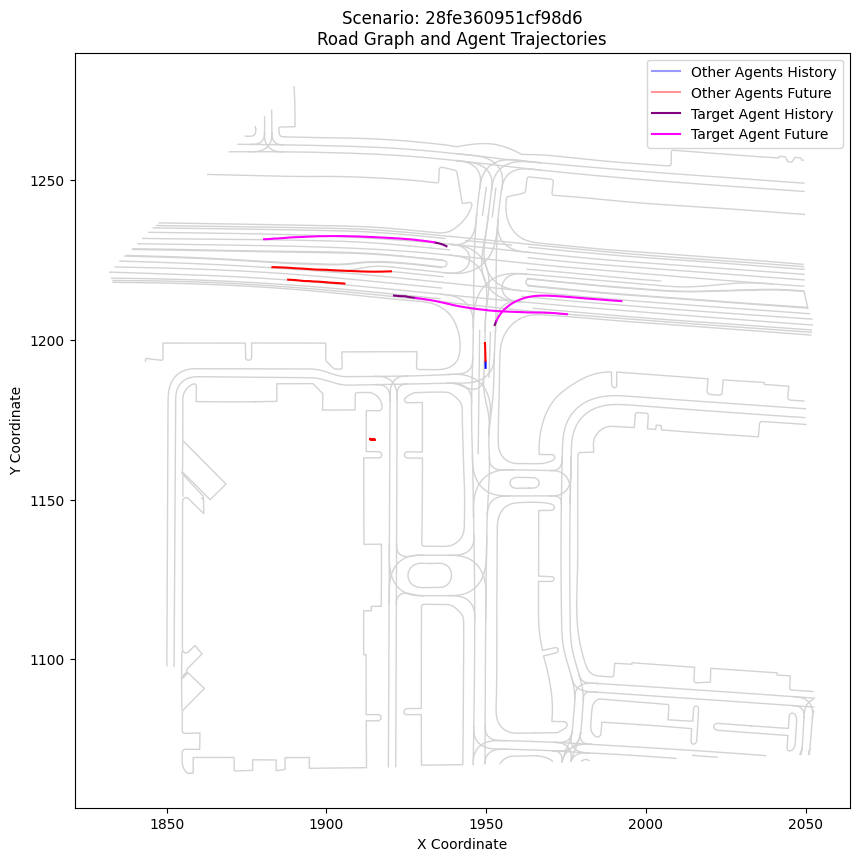

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Create a new plot figure
fig, ax = plt.subplots(figsize=(10, 10))

# Visualize the road graph (lightgray)
for map_feature in scenario.map_features:
    # Map features can be lanes, road lines, road edges, etc.
    feature_type = map_feature.WhichOneof('feature_data')
    if feature_type:
        feature_data = getattr(map_feature, feature_type)
        if hasattr(feature_data, 'polyline'):
            polyline = feature_data.polyline
            x = [point.x for point in polyline]
            y = [point.y for point in polyline]
            ax.plot(x, y, color='lightgray', linewidth=1)

# Identify the indices of agents we actually need to predict
predict_tracks = [t.track_index for t in scenario.tracks_to_predict]
# print(predict_tracks)

# Visualize the trajectories
for track_idx, track in enumerate(scenario.tracks):
    hist_x, hist_y = [], []
    fut_x, fut_y = [], []

    # Iterate through the states and separate history (<=10) and future (>10)
    for step_index, state in enumerate(track.states):
        if state.valid:
            if step_index <= 10:
                hist_x.append(state.center_x)
                hist_y.append(state.center_y)
            else:
                fut_x.append(state.center_x)
                fut_y.append(state.center_y)

    if hist_x or fut_x:
        # Highlight the agents we need to predict
        is_predict = track_idx in predict_tracks
        lw = 1.5
        alpha = 1.0

        hist_color = 'purple' if is_predict else 'blue'
        fut_color = 'magenta' if is_predict else 'red'

        # Plot History
        if hist_x:
            ax.plot(hist_x, hist_y, color=hist_color, linewidth=lw, alpha=alpha)
        # Plot Future
        if fut_x:
            ax.plot(fut_x, fut_y, color=fut_color, linewidth=lw, alpha=alpha)

# Add custom legend
custom_lines = [
    Line2D([0], [0], color='blue', lw=1.5, alpha=0.4),
    Line2D([0], [0], color='red', lw=1.5, alpha=0.4),
    Line2D([0], [0], color='purple', lw=1.5),
    Line2D([0], [0], color='magenta', lw=1.5)
]
ax.legend(custom_lines, ['Other Agents History', 'Other Agents Future', 'Target Agent History', 'Target Agent Future'])

# Add title and labels
ax.set_title(f'Scenario: {scenario.scenario_id}\nRoad Graph and Agent Trajectories')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')

# Adjust aspect ratio so map proportions are correct
ax.set_aspect('equal')

# Display the plot
plt.show()

In [5]:
import pandas as pd
from waymo_open_dataset.protos.scenario_pb2 import Track

# Map numeric object_type to string label
type_map = {
    Track.ObjectType.TYPE_UNSET: 'UNSET',
    Track.ObjectType.TYPE_VEHICLE: 'VEHICLE',
    Track.ObjectType.TYPE_PEDESTRIAN: 'PEDESTRIAN',
    Track.ObjectType.TYPE_CYCLIST: 'CYCLIST',
    Track.ObjectType.TYPE_OTHER: 'OTHER'
}

# Extract data from the already parsed 'scenario' object
data = []

for track in scenario.tracks:
    agent_id = track.id
    agent_type = type_map.get(track.object_type, 'UNKNOWN')

    for step_index, state in enumerate(track.states):
        row = {
            'agent_id': agent_id,
            'agent_type': agent_type,
            'time_step': step_index, # 0 to 90 (9.1 seconds at 10Hz)
            'valid': state.valid,    # Whether the agent was observed at this step
            'center_x': state.center_x,
            'center_y': state.center_y,
            'center_z': state.center_z,
            'length': state.length,
            'width': state.width,
            'height': state.height,
            'heading': state.heading,
            'velocity_x': state.velocity_x,
            'velocity_y': state.velocity_y
        }
        data.append(row)

# Create a pandas DataFrame
df_scenario = pd.DataFrame(data)

# agent's first 15 time steps
display(df_scenario.head(15))

# Print a summary of the columns (attributes)
# print("\nDataFrame Summary:")
# df_scenario.info()

,agent_id,agent_type,time_step,valid,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y
0,0,VEHICLE,0,True,1952.715942,1204.631348,-11.122221,5.491659,2.520635,1.991279,1.317218,0.334473,1.099854
1,0,VEHICLE,1,True,1952.746460,1204.729126,-11.119348,5.484629,2.521022,1.993847,1.320462,0.305176,0.977783
2,0,VEHICLE,2,True,1952.791382,1204.846069,-11.117373,5.456868,2.517166,1.989331,1.309195,0.449219,1.169434
3,0,VEHICLE,3,True,1952.827393,1204.948486,-11.116808,5.472248,2.518151,1.994251,1.299357,0.360107,1.024170
4,0,VEHICLE,4,True,1952.873047,1205.060669,-11.117710,5.478967,2.513201,1.997603,1.290896,0.456543,1.121826
5,0,VEHICLE,5,True,1952.918213,1205.178101,-11.116179,5.474614,2.515145,2.000176,1.281944,0.451660,1.174316
6,0,VEHICLE,6,True,1952.961060,1205.302124,-11.113897,5.487998,2.514387,2.009244,1.283490,0.428467,1.240234
7,0,VEHICLE,7,True,1953.010986,1205.416016,-11.116613,5.485196,2.520515,2.005066,1.268673,0.499268,1.138916
8,0,VEHICLE,8,True,1953.059937,1205.537476,-11.119132,5.516205,2.521922,2.007560,1.254097,0.489502,1.214600
9,0,VEHICLE,9,True,1953.118164,1205.668823,-11.120478,5.523455,2.519682,2.012224,1.243470,0.582275,1.313477


In [6]:
from waymo_open_dataset.protos import scenario_pb2
from waymo_open_dataset.protos import map_pb2

def print_protobuf_schema(message_class, title):
    print(f"\n=== {title} ===")
    # Extract all the field names from the protobuf descriptor
    fields = list(message_class.DESCRIPTOR.fields_by_name.keys())
    for field in fields:
        print(f" - {field}")

# Print the attributes for the main components of the dataset
print_protobuf_schema(scenario_pb2.Scenario, "SCENARIO (The 9-second clip)")
print_protobuf_schema(scenario_pb2.Track, "TRACK (An individual agent)")
print_protobuf_schema(scenario_pb2.ObjectState, "TRACK STATE (An agent at a specific 0.1s time step)")
print_protobuf_schema(map_pb2.MapFeature, "MAP FEATURE (A single static road element)")
print_protobuf_schema(scenario_pb2.DynamicMapState, "DYNAMIC MAP STATE (Traffic lights at a specific time step)")


=== SCENARIO (The 9-second clip) ===
 - scenario_id
 - timestamps_seconds
 - current_time_index
 - tracks
 - dynamic_map_states
 - map_features
 - sdc_track_index
 - objects_of_interest
 - tracks_to_predict
 - compressed_frame_laser_data
 - frame_camera_tokens

=== TRACK (An individual agent) ===
 - id
 - object_type
 - states

=== TRACK STATE (An agent at a specific 0.1s time step) ===
 - center_x
 - center_y
 - center_z
 - length
 - width
 - height
 - heading
 - velocity_x
 - velocity_y
 - valid

=== MAP FEATURE (A single static road element) ===
 - id
 - lane
 - road_line
 - road_edge
 - stop_sign
 - crosswalk
 - speed_bump
 - driveway

=== DYNAMIC MAP STATE (Traffic lights at a specific time step) ===
 - lane_states


## Scalable Data Pipeline for Transformer Training

To process hundreds of thousands of scenarios from the entire training bucket, we cannot load all data into memory at once.
Here, we define a Python generator that processes scenarios on-the-fly and wrap it in a `tf.data.Dataset`. This pipeline extracts the exact same historical, map, and future features, but pads the map points to a fixed size so the tensors can be batched for deep learning.

In [7]:
import numpy as np
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

def extract_scenario_features(scenario, max_map_points=1000):
    """Processes a single scenario and extracts features for valid agents."""
    allowed_types = [scenario_pb2.Track.ObjectType.TYPE_VEHICLE,
                     scenario_pb2.Track.ObjectType.TYPE_PEDESTRIAN,
                     scenario_pb2.Track.ObjectType.TYPE_CYCLIST]

    # 1. Extract Map Points
    map_points = []
    for map_feature in scenario.map_features:
        feature_type = map_feature.WhichOneof('feature_data')
        if feature_type:
            feature_data = getattr(map_feature, feature_type)
            if hasattr(feature_data, 'polyline'):
                for point in feature_data.polyline:
                    map_points.append([point.x, point.y])
    map_points_array = np.array(map_points) if map_points else np.empty((0, 2))

    agents_hist = []
    agents_map = []
    agents_fut = []

    # 2. Process Tracks
    for track in scenario.tracks:
        if track.object_type not in allowed_types:
            continue

        states = track.states
        if len(states) < 91:
            continue

        # Check validity (0-10 must be valid, 90 must be valid)
        if not all(states[i].valid for i in range(11)) or not states[90].valid:
            continue

        # Reference state at t=10
        ref_state = states[10]
        ref_x, ref_y, ref_heading = ref_state.center_x, ref_state.center_y, ref_state.heading
        cos_h, sin_h = np.cos(-ref_heading), np.sin(-ref_heading)

        # Extract History (0-10)
        hist_features = np.zeros((11, 7)) # local_x, local_y, local_heading, speed, accel, yaw_rate, dist_map
        speeds = []
        for i in range(11):
            s = states[i]
            dx, dy = s.center_x - ref_x, s.center_y - ref_y
            local_x = dx * cos_h - dy * sin_h
            local_y = dx * sin_h + dy * cos_h
            local_heading = s.heading - ref_heading
            speed = np.sqrt(s.velocity_x**2 + s.velocity_y**2)
            speeds.append(speed)

            hist_features[i, :4] = [local_x, local_y, local_heading, speed]

        # Kinematics
        for i in range(1, 11):
            hist_features[i, 4] = (speeds[i] - speeds[i-1]) / 0.1 # accel
            dh = states[i].heading - states[i-1].heading
            dh = (dh + np.pi) % (2 * np.pi) - np.pi
            hist_features[i, 5] = dh / 0.1 # yaw rate

        # Nearest Map Distance
        if len(map_points_array) > 0:
            dists = np.linalg.norm(map_points_array - np.array([ref_x, ref_y]), axis=1)
            min_dist = np.min(dists)
        else:
            min_dist = 0.0
        hist_features[:, 6] = min_dist

        # Extract Future (11-90)
        fut_features = np.zeros((80, 2))
        for i in range(11, 91):
            s = states[i]
            dx, dy = s.center_x - ref_x, s.center_y - ref_y
            local_x = dx * cos_h - dy * sin_h
            local_y = dx * sin_h + dy * cos_h
            fut_features[i-11] = [local_x, local_y]

        # Transform Map to Agent-Centric
        if len(map_points_array) > 0:
            dx_map = map_points_array[:, 0] - ref_x
            dy_map = map_points_array[:, 1] - ref_y
            local_map_x = dx_map * cos_h - dy_map * sin_h
            local_map_y = dx_map * sin_h + dy_map * cos_h
            local_map = np.stack([local_map_x, local_map_y], axis=1)
        else:
            local_map = np.zeros((0, 2))

        # Pad or truncate map points to fixed size for batching
        if len(local_map) > max_map_points:
            # Optional: sort by distance to origin and take closest
            dists = np.linalg.norm(local_map, axis=1)
            closest_idx = np.argsort(dists)[:max_map_points]
            local_map = local_map[closest_idx]
        elif len(local_map) < max_map_points:
            pad_size = max_map_points - len(local_map)
            local_map = np.pad(local_map, ((0, pad_size), (0, 0)), mode='constant')

        agents_hist.append(hist_features)
        agents_map.append(local_map)
        agents_fut.append(fut_features)

    return agents_hist, agents_map, agents_fut

def waymo_generator(file_paths, max_scenarios=None):
    """Generator that yields (inputs, targets) for each valid agent."""
    dataset = tf.data.TFRecordDataset(file_paths)
    scenario_count = 0

    for record in dataset:
        if max_scenarios and scenario_count >= max_scenarios:
            break

        scenario = scenario_pb2.Scenario()
        scenario.ParseFromString(record.numpy())

        hists, maps, futs = extract_scenario_features(scenario)

        for h, m, f in zip(hists, maps, futs):
            # Yield inputs dict and target array
            yield {'history': h, 'map_context': m}, f

        scenario_count += 1


In [21]:
# --- CONFIGURATION TOGGLE ---
# The full dataset (1000 files) takes far too long on a CPU.
# Let's use a 10% subset (100 files) to get good results in a fraction of the time.
NUM_FILES_TO_USE = 100
subset_train_files = train_files[:NUM_FILES_TO_USE]

# Standard ML Batch Size
BATCH_SIZE = 64

output_signature = (
    {
        'history': tf.TensorSpec(shape=(11, 7), dtype=tf.float32),
        'map_context': tf.TensorSpec(shape=(1000, 2), dtype=tf.float32)
    },
    tf.TensorSpec(shape=(80, 2), dtype=tf.float32) # Future targets
)

# Create dataset from the subset of files
train_dataset = tf.data.Dataset.from_generator(
    lambda: waymo_generator(subset_train_files, max_scenarios=None),
    output_signature=output_signature
)

# Batch and prefetch for performance
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Test the pipeline
for inputs, targets in train_dataset.take(1):
    print("Batched History Shape:", inputs['history'].shape)
    print("Batched Map Context Shape:", inputs['map_context'].shape)
    print("Batched Future Targets Shape:", targets.shape)
    print(f"Dataset is ready! Using {NUM_FILES_TO_USE} files instead of all {len(train_files)}.")

Batched History Shape: (64, 11, 7)
Batched Map Context Shape: (64, 1000, 2)
Batched Future Targets Shape: (64, 80, 2)
Dataset is ready! Using 100 files instead of all 1000.


In [9]:
import tensorflow as tf

# Define validation set for training (the next 20 files after the training subset)
NUM_VAL_FILES_FOR_TRAINING = 20
val_files_for_training = train_files[NUM_FILES_TO_USE : NUM_FILES_TO_USE + NUM_VAL_FILES_FOR_TRAINING]

val_dataset_for_training = tf.data.Dataset.from_generator(
    lambda: waymo_generator(val_files_for_training, max_scenarios=None),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Validation dataset ready! Using {len(val_files_for_training)} files for validation during training.")

Validation dataset ready! Using 20 files for validation during training.


Primary attributes to use:
* **Inputs (History):** You will typically use `time_step` 0 through 10. The features `center_x`, `center_y`, `velocity_x`, `velocity_y`, `heading`, and bounding box sizes (`length`, `width`) act as your model inputs.

* **Outputs (Future/Target):** You will try to predict the `center_x` and `center_y` (and sometimes `heading`) for `time_step` 11 through 90.
* **Validity:** The `valid` flag is crucial. You should only calculate loss or extract features when `valid == True`.

## Dataset Analysis and Feature Selection


1. Analyze the features within the parsed scenario, such as agent types and track lengths, to prepare for feature extraction and modeling.


In [10]:
from collections import Counter
import numpy as np
from waymo_open_dataset.protos.scenario_pb2 import Track

# Map numeric object_type to string label
type_map = {
    Track.ObjectType.TYPE_UNSET: 'UNSET',
    Track.ObjectType.TYPE_VEHICLE: 'VEHICLE',
    Track.ObjectType.TYPE_PEDESTRIAN: 'PEDESTRIAN',
    Track.ObjectType.TYPE_CYCLIST: 'CYCLIST',
    Track.ObjectType.TYPE_OTHER: 'OTHER'
}

agent_types = []
track_lengths = []

for track in scenario.tracks:
    agent_types.append(type_map.get(track.object_type, 'UNKNOWN'))
    valid_states = sum(1 for state in track.states if state.valid)
    track_lengths.append(valid_states)

# Count agent types
type_counts = Counter(agent_types)
print('Agent Type Distribution:')
for agent_type, count in type_counts.items():
    print(f'  {agent_type}: {count}')

# Track length statistics
print('\nTrack Length Statistics (Valid States):')
print(f'  Min: {np.min(track_lengths)}')
print(f'  Max: {np.max(track_lengths)}')
print(f'  Mean: {np.mean(track_lengths):.2f}')


Agent Type Distribution:
  VEHICLE: 15
  CYCLIST: 1

Track Length Statistics (Valid States):
  Min: 7
  Max: 91
  Mean: 68.62


### Data Filtering
Applying filters for valid history, valid future targets, and specific agent types.

In [11]:
# 1. Filter out unwanted agent types (Keep only Vehicles, Pedestrians, Cyclists)
allowed_types = ['VEHICLE', 'PEDESTRIAN', 'CYCLIST']
df_filtered = df_scenario[df_scenario['agent_type'].isin(allowed_types)]

valid_agent_ids = []

# Group by agent to evaluate their track length and validity
for agent_id, group in df_filtered.groupby('agent_id'):
    # Split into history (0-10) and future (11-90)
    history = group[group['time_step'] <= 10]
    future = group[group['time_step'] > 10]

    # Condition A: Must have a fully valid history (11 frames)
    has_full_history = history['valid'].all() and len(history) == 11

    # Condition B: Must have a valid final target (step 90) to ensure a long future track
    has_final_target = future[(future['time_step'] == 90) & (future['valid'] == True)].any().any()

    if has_full_history and has_final_target:
        valid_agent_ids.append(agent_id)

# Apply the final filter to keep only fully qualified agents
df_training_ready = df_filtered[df_filtered['agent_id'].isin(valid_agent_ids)]

print(f"Original rows: {len(df_scenario)} | Original agents: {df_scenario['agent_id'].nunique()}")
print(f"Filtered rows: {len(df_training_ready)} | Qualified agents: {len(valid_agent_ids)}")
print(f"Agents ready for training: {valid_agent_ids}")

# Preview the cleaned data for the first qualified agent
if valid_agent_ids:
    display(df_training_ready[df_training_ready['agent_id'] == valid_agent_ids[0]].head())

Original rows: 1456 | Original agents: 16
Filtered rows: 819 | Qualified agents: 9
Agents ready for training: [0, 2, 3, 4, 5, 6, 11, 12, 142]


,agent_id,agent_type,time_step,valid,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y
0,0,VEHICLE,0,True,1952.715942,1204.631348,-11.122221,5.491659,2.520635,1.991279,1.317218,0.334473,1.099854
1,0,VEHICLE,1,True,1952.746460,1204.729126,-11.119348,5.484629,2.521022,1.993847,1.320462,0.305176,0.977783
2,0,VEHICLE,2,True,1952.791382,1204.846069,-11.117373,5.456868,2.517166,1.989331,1.309195,0.449219,1.169434
3,0,VEHICLE,3,True,1952.827393,1204.948486,-11.116808,5.472248,2.518151,1.994251,1.299357,0.360107,1.024170
4,0,VEHICLE,4,True,1952.873047,1205.060669,-11.117710,5.478967,2.513201,1.997603,1.290896,0.456543,1.121826


### Feature Engineering
Feature engineering pipeline for the filtered Waymo dataset tracks:
1. transform the absolute map coordinates into agent-centric local coordinates,
2. extract kinematic features (such as speed, acceleration, and yaw rate) from the historical data
3. integrate map context features (such as distance from the road) from the surrounding road graph
4. format these engineered features into standardized tensors suitable for deep learning and summarize the resulting tensor shapes

### Agent-Centric Coordinate Transformation
Transform absolute map coordinates into agent-centric local coordinates based on the agent's position and heading at time step 10.


In [12]:
import numpy as np

def transform_to_agent_centric(df):
    df_transformed = df.copy()
    df_transformed['local_x'] = 0.0
    df_transformed['local_y'] = 0.0
    df_transformed['local_heading'] = 0.0

    for agent_id, group in df_transformed.groupby('agent_id'):
        # Get reference state at time_step 10
        ref_state = group[group['time_step'] == 10]
        if ref_state.empty:
            continue

        ref_x = ref_state['center_x'].values[0]
        ref_y = ref_state['center_y'].values[0]
        ref_heading = ref_state['heading'].values[0]

        # Get indices for this agent
        idx = group.index

        # Translate
        dx = df_transformed.loc[idx, 'center_x'] - ref_x
        dy = df_transformed.loc[idx, 'center_y'] - ref_y

        # Rotate
        cos_h = np.cos(-ref_heading)
        sin_h = np.sin(-ref_heading)

        df_transformed.loc[idx, 'local_x'] = dx * cos_h - dy * sin_h
        df_transformed.loc[idx, 'local_y'] = dx * sin_h + dy * cos_h
        df_transformed.loc[idx, 'local_heading'] = df_transformed.loc[idx, 'heading'] - ref_heading

    return df_transformed

df_training_ready = transform_to_agent_centric(df_training_ready)

# Display verification for time_step 10
display(df_training_ready[df_training_ready['time_step'] == 10][['agent_id', 'time_step', 'center_x', 'center_y', 'local_x', 'local_y', 'heading', 'local_heading']].head())

# Display general head
display(df_training_ready.head())

,agent_id,time_step,center_x,center_y,local_x,local_y,heading,local_heading
10,0,10,1953.181763,1205.798828,0.0,0.0,1.238432,0.0
192,2,10,1926.748047,1193.996948,0.0,-0.0,1.627307,0.0
283,3,10,1921.610596,1193.682617,0.0,-0.0,1.630895,0.0
374,4,10,1927.639893,1168.720825,0.0,0.0,6.242266,0.0
465,5,10,1916.531006,1194.255981,0.0,0.0,7.777323,0.0


,agent_id,agent_type,time_step,valid,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y,local_x,local_y,local_heading
0,0,VEHICLE,0,True,1952.715942,1204.631348,-11.122221,5.491659,2.520635,1.991279,1.317218,0.334473,1.099854,-1.255576,0.059403,0.078786
1,0,VEHICLE,1,True,1952.746460,1204.729126,-11.119348,5.484629,2.521022,1.993847,1.320462,0.305176,0.977783,-1.153191,0.062459,0.082030
2,0,VEHICLE,2,True,1952.791382,1204.846069,-11.117373,5.456868,2.517166,1.989331,1.309195,0.449219,1.169434,-1.027991,0.058151,0.070763
3,0,VEHICLE,3,True,1952.827393,1204.948486,-11.116808,5.472248,2.518151,1.994251,1.299357,0.360107,1.024170,-0.919429,0.057528,0.060925
4,0,VEHICLE,4,True,1952.873047,1205.060669,-11.117710,5.478967,2.513201,1.997603,1.290896,0.456543,1.121826,-0.798490,0.050975,0.052464


## Kinematic Feature Extraction

Calculate advanced kinematic features from the historical track data (time steps 0-10).


In [13]:
def calculate_kinematic_features(df):
    df_k = df.copy()
    dt = 0.1 # 10Hz data

    # Calculate speed (magnitude of velocity vector)
    df_k['speed'] = np.sqrt(df_k['velocity_x']**2 + df_k['velocity_y']**2)

    # Initialize acceleration and yaw_rate
    df_k['acceleration'] = 0.0
    df_k['yaw_rate'] = 0.0

    for agent_id, group in df_k.groupby('agent_id'):
        idx = group.index

        # Acceleration: dv/dt
        speed_diff = group['speed'].diff()
        speed_diff.iloc[0] = 0.0 # Handle first element
        df_k.loc[idx, 'acceleration'] = speed_diff / dt

        # Yaw rate: d(heading)/dt
        # Need to handle angle wrapping, but for simplicity here we just take the diff
        heading_diff = group['heading'].diff()
        heading_diff.iloc[0] = 0.0

        # Adjust for wrapping between -pi and pi
        heading_diff = (heading_diff + np.pi) % (2 * np.pi) - np.pi

        df_k.loc[idx, 'yaw_rate'] = heading_diff / dt

    return df_k

# Apply only to historical data (steps 0-10) or compute for all and filter if needed later.
# The instructions say "Apply these calculations to the historical data (time steps 0-10) and append..."
# It's usually easier to compute for all valid steps. Let's compute for all and then we can look at 0-10.
df_training_ready = calculate_kinematic_features(df_training_ready)

# Display sample of historical steps
display(df_training_ready[df_training_ready['time_step'] <= 10][['agent_id', 'time_step', 'speed', 'acceleration', 'yaw_rate']].head(15))


,agent_id,time_step,speed,acceleration,yaw_rate
0,0,0,1.149587,0.000000,0.000000
1,0,1,1.024301,-1.252859,0.032437
2,0,2,1.252746,2.284451,-0.112669
3,0,3,1.085634,-1.671119,-0.098373
4,0,4,1.211167,1.255329,-0.084617
5,0,5,1.258180,0.470126,-0.089519
6,0,6,1.312160,0.539809,0.015464
7,0,7,1.243542,-0.686180,-0.148171
8,0,8,1.309528,0.659859,-0.145762
9,0,9,1.436755,1.272268,-0.106267


## Map Context Integration

Extract spatial relationships by computing the relative distance from each agent to the nearest map feature, in agent's reference position (time_step 10).


In [14]:
import numpy as np

# 1 & 2. Collect map points
map_points = []
for map_feature in scenario.map_features:
    feature_type = map_feature.WhichOneof('feature_data')
    if feature_type:
        feature_data = getattr(map_feature, feature_type)
        if hasattr(feature_data, 'polyline'):
            for point in feature_data.polyline:
                map_points.append([point.x, point.y])

map_points_array = np.array(map_points)

# 3. Initialize column
df_training_ready['dist_to_nearest_map'] = 0.0

# 4, 5 & 6. Calculate distances and assign
for agent_id, group in df_training_ready.groupby('agent_id'):
    ref_state = group[group['time_step'] == 10]
    if ref_state.empty:
        continue

    ref_x = ref_state['center_x'].values[0]
    ref_y = ref_state['center_y'].values[0]

    # Calculate Euclidean distances
    if len(map_points_array) > 0:
        distances = np.linalg.norm(map_points_array - np.array([ref_x, ref_y]), axis=1)
        min_dist = np.min(distances)
    else:
        min_dist = np.nan # Or 0.0 if no map features

    df_training_ready.loc[group.index, 'dist_to_nearest_map'] = min_dist

# 7. Display verification
display(df_training_ready[['agent_id', 'time_step', 'dist_to_nearest_map']].head(15))


,agent_id,time_step,dist_to_nearest_map
0,0,0,0.124269
1,0,1,0.124269
2,0,2,0.124269
3,0,3,0.124269
4,0,4,0.124269
5,0,5,0.124269
6,0,6,0.124269
7,0,7,0.124269
8,0,8,0.124269
9,0,9,0.124269


## Format Tensors for Deep Learning

Structure the engineered historical features, map context features, and future target coordinates into standardized NumPy arrays suitable for training a deep learning model.


In [15]:
import numpy as np

# Define the list of historical feature column names to extract
historical_features = ['local_x', 'local_y', 'local_heading', 'speed', 'acceleration', 'yaw_rate', 'dist_to_nearest_map']

history_tensors = []
future_tensors = []

# Iterate through each unique agent_id in df_training_ready
for agent_id in df_training_ready['agent_id'].unique():
    agent_data = df_training_ready[df_training_ready['agent_id'] == agent_id]

    # Extract historical features for time steps 0 to 10
    history_data = agent_data[agent_data['time_step'] <= 10]
    # Ensure we have exactly 11 steps and order them by time_step
    history_data = history_data.sort_values('time_step')

    if len(history_data) == 11:
        history_array = history_data[historical_features].values
        history_tensors.append(history_array)

        # Extract future target coordinates (local_x, local_y) for time steps 11 to 90
        future_data = agent_data[(agent_data['time_step'] > 10) & (agent_data['time_step'] <= 90)]
        future_data = future_data.sort_values('time_step')

        # Ensure we have exactly 80 future steps
        if len(future_data) == 80:
            future_array = future_data[['local_x', 'local_y']].values
            future_tensors.append(future_array)
        else:
            # If future data is missing, we shouldn't append history to keep them aligned
            history_tensors.pop()

# Convert lists to NumPy arrays
history_tensor_np = np.array(history_tensors)
future_tensor_np = np.array(future_tensors)

# Print shapes to verify
print(f"Historical features tensor shape: {history_tensor_np.shape}")
print(f"Future targets tensor shape: {future_tensor_np.shape}")

Historical features tensor shape: (9, 11, 7)
Future targets tensor shape: (9, 80, 2)


## Implement Map Coordinate Transformation

Transforming map features into individual agent-centric coordinate frames to provide richer spatial context for prediction models - apply the same translation and rotation logic (agen't reference at time step 10)


In [16]:
import numpy as np

def transform_map_to_agent_centric(df, map_points):
    transformed_maps = {}
    for agent_id, group in df.groupby('agent_id'):
        ref_state = group[group['time_step'] == 10]
        if ref_state.empty:
            continue

        ref_x = ref_state['center_x'].values[0]
        ref_y = ref_state['center_y'].values[0]
        ref_heading = ref_state['heading'].values[0]

        # Translate
        dx = map_points[:, 0] - ref_x
        dy = map_points[:, 1] - ref_y

        # Rotate
        cos_h = np.cos(-ref_heading)
        sin_h = np.sin(-ref_heading)

        local_x = dx * cos_h - dy * sin_h
        local_y = dx * sin_h + dy * cos_h

        transformed_maps[agent_id] = np.stack([local_x, local_y], axis=1)

    return transformed_maps

# map_points_array was calculated in a previous cell
agent_centric_maps = transform_map_to_agent_centric(df_training_ready, map_points_array)

# Display sample for the first agent
first_agent_id = list(agent_centric_maps.keys())[0]
print(f"Sample of transformed map points for agent {first_agent_id}:")
print(agent_centric_maps[first_agent_id][:5])

Sample of transformed map points for agent 0:
[[ 79.00095854 -74.363112  ]
 [ 78.87996889 -73.89640852]
 [ 79.13381772 -73.69641509]
 [ 79.38766654 -73.49642166]
 [ 79.29944006 -73.02822085]]


## Refine Feature Tensor Creation

Refine the feature tensor creation logic to include the newly transformed local map coordinates for each agent.

In [17]:
import numpy as np

historical_features = ['local_x', 'local_y', 'local_heading', 'speed', 'acceleration', 'yaw_rate', 'dist_to_nearest_map']

history_tensors = []
future_tensors = []
map_tensors = []

for agent_id in df_training_ready['agent_id'].unique():
    agent_data = df_training_ready[df_training_ready['agent_id'] == agent_id]

    history_data = agent_data[agent_data['time_step'] <= 10].sort_values('time_step')

    if len(history_data) == 11:
        future_data = agent_data[(agent_data['time_step'] > 10) & (agent_data['time_step'] <= 90)].sort_values('time_step')

        if len(future_data) == 80:
            history_tensors.append(history_data[historical_features].values)
            future_tensors.append(future_data[['local_x', 'local_y']].values)

            if agent_id in agent_centric_maps:
                map_tensors.append(agent_centric_maps[agent_id])

history_tensor_np = np.array(history_tensors)
future_tensor_np = np.array(future_tensors)
map_tensor_np = np.array(map_tensors)

print(f"Historical features tensor shape: {history_tensor_np.shape}")
print(f"Future targets tensor shape: {future_tensor_np.shape}")
print(f"Map context tensor shape: {map_tensor_np.shape}")

Historical features tensor shape: (9, 11, 7)
Future targets tensor shape: (9, 80, 2)
Map context tensor shape: (9, 17969, 2)


## Visualize Coordinate Systems

Create side-by-side scatter plots comparing the original global map and trajectory coordinates with the transformed agent-centric coordinates for a specific target agent.


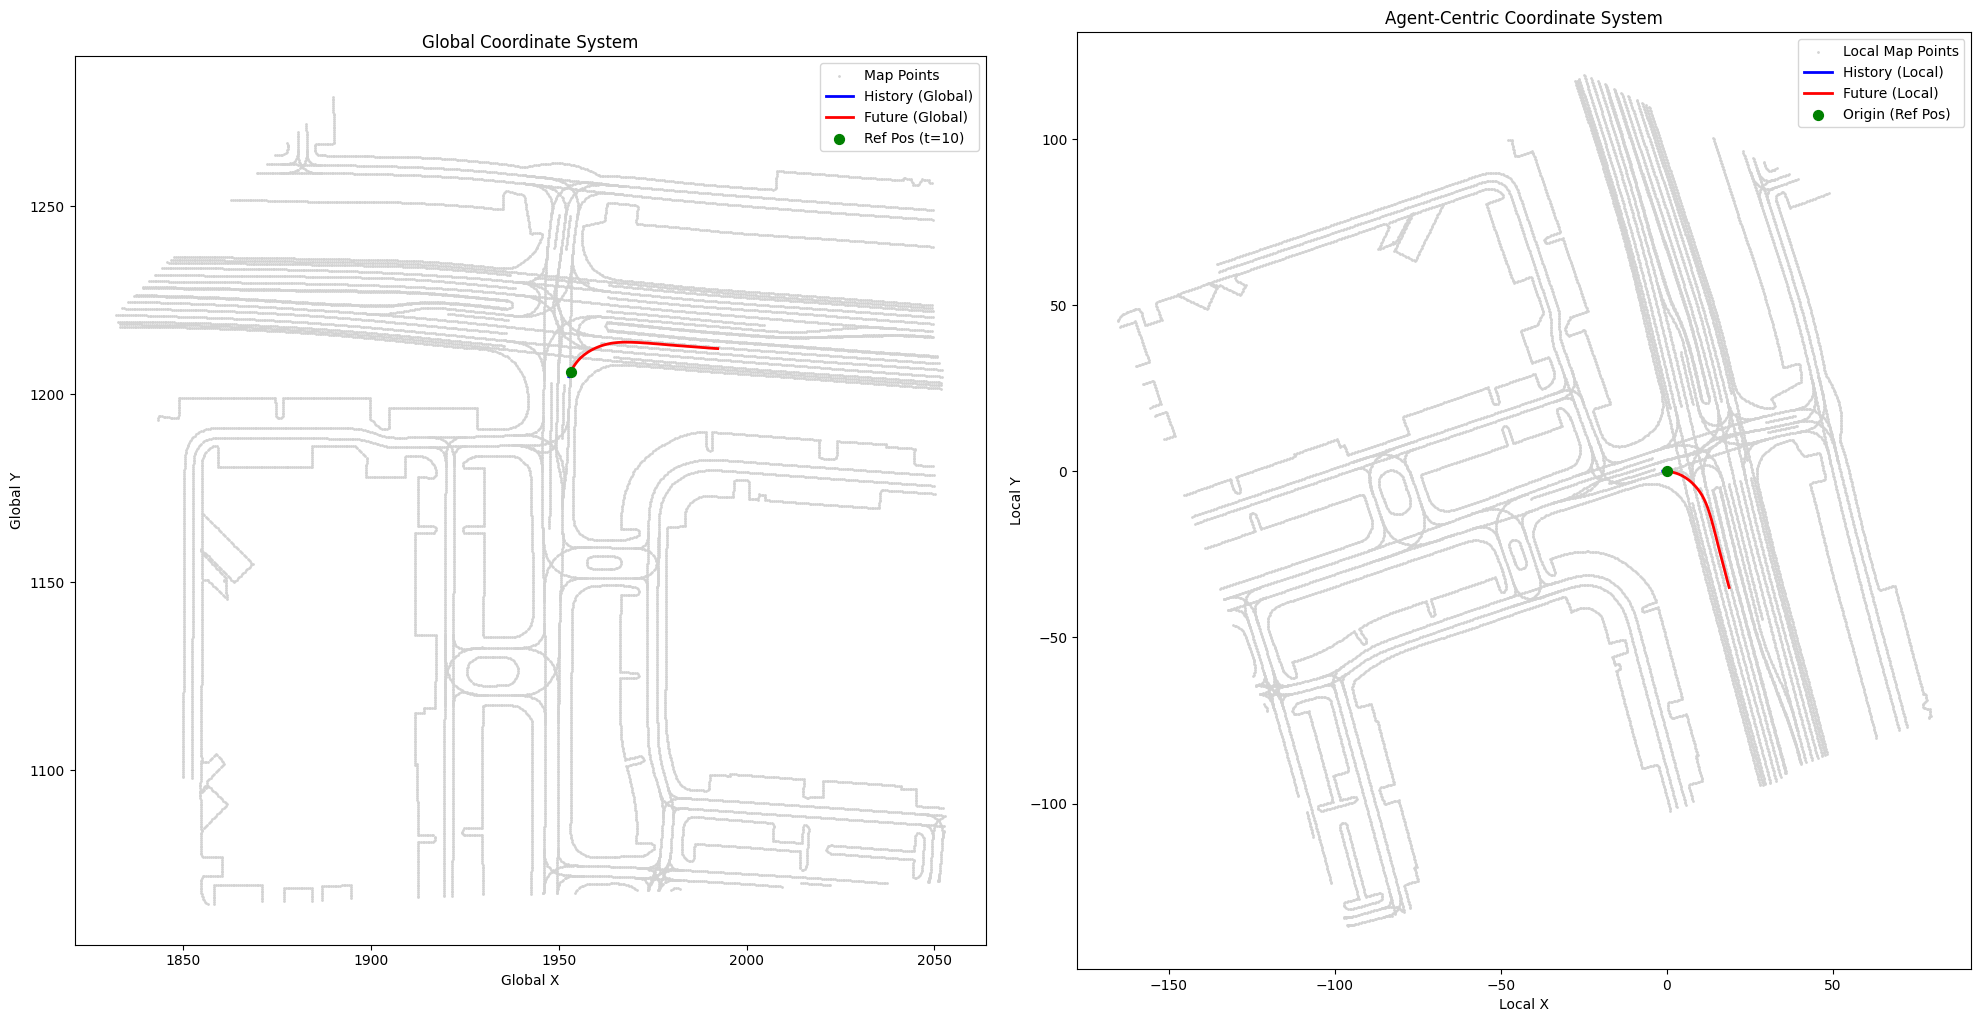

In [18]:
import matplotlib.pyplot as plt

# Select target agent
target_agent_id = 0

# Extract agent trajectory data
agent_df = df_training_ready[df_training_ready['agent_id'] == target_agent_id]
hist_df = agent_df[agent_df['time_step'] <= 10]
fut_df = agent_df[agent_df['time_step'] > 10]

# Extract map data
global_map = map_points_array
local_map = agent_centric_maps[target_agent_id]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot Global Coordinate System
ax1.scatter(global_map[:, 0], global_map[:, 1], color='lightgray', s=1, label='Map Points')
ax1.plot(hist_df['center_x'], hist_df['center_y'], color='blue', linewidth=2, label='History (Global)')
ax1.plot(fut_df['center_x'], fut_df['center_y'], color='red', linewidth=2, label='Future (Global)')
ax1.scatter(hist_df[hist_df['time_step'] == 10]['center_x'], hist_df[hist_df['time_step'] == 10]['center_y'], color='green', s=50, label='Ref Pos (t=10)', zorder=5)
ax1.set_title('Global Coordinate System')
ax1.set_xlabel('Global X')
ax1.set_ylabel('Global Y')
ax1.set_aspect('equal')
ax1.legend()

# Plot Agent-Centric Coordinate System
ax2.scatter(local_map[:, 0], local_map[:, 1], color='lightgray', s=1, label='Local Map Points')
ax2.plot(hist_df['local_x'], hist_df['local_y'], color='blue', linewidth=2, label='History (Local)')
ax2.plot(fut_df['local_x'], fut_df['local_y'], color='red', linewidth=2, label='Future (Local)')
ax2.scatter(0, 0, color='green', s=50, label='Origin (Ref Pos)', zorder=5)
ax2.set_title('Agent-Centric Coordinate System')
ax2.set_xlabel('Local X')
ax2.set_ylabel('Local Y')
ax2.set_aspect('equal')
ax2.legend()

plt.tight_layout()
plt.show()

## 1. Standard Physics-Based Baselines in Trajectory Prediction

When developing complex deep learning models for trajectory prediction, it is standard practice to compare their performance against simpler, physics-based kinematic models. These models rely on the basic laws of motion and extrapolate future positions based on the agent's recent historical state.

1.  **Constant Velocity (CV) Model:**
    *   **Assumption:** The agent will continue moving at the exact same speed and in the exact same direction as its most recently observed state.
    *   **Mechanism:** It ignores any acceleration or turning behavior, simply projecting the current velocity vector forward in time.

2.  **Constant Turn Rate and Velocity (CTRV) Model:**
    *   **Assumption:** The agent will maintain its current speed (constant velocity magnitude) and its current rate of turning (constant yaw rate).
    *   **Mechanism:** This model is slightly more sophisticated than the CV model because it can capture curving trajectories. It uses the agent's current heading, speed, and yaw rate to extrapolate a curved path.

**Why are these useful baselines?**

*   **Simplicity and Interpretability:** They are completely transparent and require no training. The predictions are derived from straightforward mathematical equations.
*   **Performance on Short Horizons:** For very short prediction horizons (e.g., 1-2 seconds), these models are surprisingly accurate, as vehicles and pedestrians typically cannot change their kinematics instantaneously.
*   **Sanity Check:** If a complex, computationally expensive deep learning model cannot outperform a simple CV or CTRV model, it indicates a fundamental flaw in the model's design or training process. They provide a foundational lower bound for expected performance.

## Implement Physics-Based Baseline - CV

Implement a standard physics-based trajectory prediction model (CV) using the engineered historical features to project future vehicle positions.


In [ ]:
import numpy as np
import pandas as pd

def predict_cv_model(df, history_steps=10, future_steps=80, dt=0.1):
    predictions = []
    for agent_id, group in df.groupby('agent_id'):
        ref_state = group[group['time_step'] == history_steps]
        if ref_state.empty:
            continue

        # Extract state at t=10
        ref_x = ref_state['center_x'].values[0]
        ref_y = ref_state['center_y'].values[0]
        velocity_x = ref_state['velocity_x'].values[0]
        velocity_y = ref_state['velocity_y'].values[0]

        # Generate future time steps
        future_times = np.arange(1, future_steps + 1) * dt

        # Predict future positions (Global coordinates)
        pred_x_global = ref_x + velocity_x * future_times
        pred_y_global = ref_y + velocity_y * future_times

        # Also predict in agent-centric local coordinates for direct comparison with target tensors
        # At t=10, local position is (0,0) and local velocity aligns with local_heading
        # Actually, let's just project using the local velocity.
        # local_x at t=10 is 0, local_y at t=10 is 0.
        # We need local velocity. The velocity magnitude is 'speed'.
        speed = ref_state['speed'].values[0]
        # The local heading at t=10 is 0 by definition, so velocity is entirely along local X.
        # Wait, velocity vector might not perfectly align with heading.
        # Let's project global predicted positions to local coordinates using the same transformation.
        ref_heading = ref_state['heading'].values[0]
        cos_h = np.cos(-ref_heading)
        sin_h = np.sin(-ref_heading)

        dx = pred_x_global - ref_x
        dy = pred_y_global - ref_y

        pred_x_local = dx * cos_h - dy * sin_h
        pred_y_local = dx * sin_h + dy * cos_h

        # Store predictions
        for i, t_step in enumerate(range(history_steps + 1, history_steps + future_steps + 1)):
            predictions.append({
                'agent_id': agent_id,
                'time_step': t_step,
                'pred_x_global': pred_x_global[i],
                'pred_y_global': pred_y_global[i],
                'pred_x_local': pred_x_local[i],
                'pred_y_local': pred_y_local[i]
            })

    return pd.DataFrame(predictions)

# Apply the CV model
df_cv_predictions = predict_cv_model(df_training_ready)

# Display the predictions for the first agent
display(df_cv_predictions.head())

# Create a numpy array of local predictions to match the shape of future_tensor_np
cv_pred_tensors = []
for agent_id in df_training_ready['agent_id'].unique():
    agent_preds = df_cv_predictions[df_cv_predictions['agent_id'] == agent_id]
    if len(agent_preds) == 80:
        cv_pred_tensors.append(agent_preds[['pred_x_local', 'pred_y_local']].values)

cv_pred_tensor_np = np.array(cv_pred_tensors)
print(f"\nCV Predictions tensor shape: {cv_pred_tensor_np.shape}")


,agent_id,time_step,pred_x_global,pred_y_global,pred_x_local,pred_y_local
0,0,11,1953.245361,1205.928833,0.143641,-0.017700
1,0,12,1953.308960,1206.058838,0.287282,-0.035400
2,0,13,1953.372559,1206.188843,0.430923,-0.053101
3,0,14,1953.436157,1206.318848,0.574564,-0.070801
4,0,15,1953.499756,1206.448853,0.718205,-0.088501



CV Predictions tensor shape: (9, 80, 2)


## Evaluate Baseline Performance

Calculate ADE and FDE by comparing the baseline predictions against the ground truth future targets.


In [ ]:
import numpy as np

# Calculate distances between predictions and ground truth
distances = np.linalg.norm(cv_pred_tensor_np - future_tensor_np, axis=2)

# Calculate ADE (Average Displacement Error) over all future steps
ade = np.mean(distances)

# Calculate FDE (Final Displacement Error) at the last future step (index -1)
fde = np.mean(distances[:, -1])

print(f"Constant Velocity Model Performance:")
print(f"  Average Displacement Error (ADE): {ade:.4f} meters")
print(f"  Final Displacement Error (FDE):   {fde:.4f} meters")


Constant Velocity Model Performance:
  Average Displacement Error (ADE): 1.7452 meters
  Final Displacement Error (FDE):   4.9273 meters


Visualize the predicted future trajectories vs actual future trajectories and local map context.

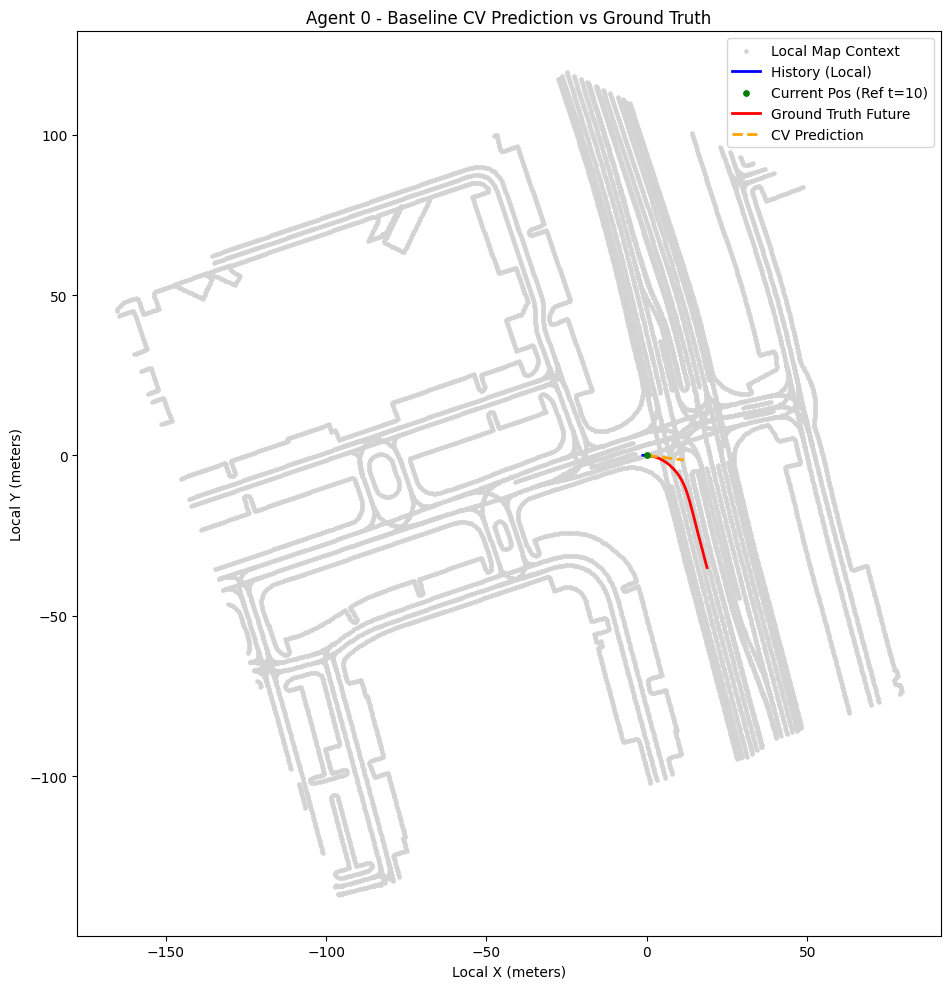

In [ ]:
import matplotlib.pyplot as plt

# Select the same target agent as before
target_agent_id = 0
agent_idx = list(df_training_ready['agent_id'].unique()).index(target_agent_id)

# Extract data for visualization
local_map = agent_centric_maps[target_agent_id]
hist_traj = history_tensor_np[agent_idx, :, :2]  # local_x, local_y
ground_truth_fut = future_tensor_np[agent_idx, :, :2]
pred_fut = cv_pred_tensor_np[agent_idx, :, :2]

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot local map context
ax.scatter(local_map[:, 0], local_map[:, 1], color='lightgray', s=5, label='Local Map Context')

# Plot historical trajectory
ax.plot(hist_traj[:, 0], hist_traj[:, 1], color='blue', linewidth=2, label='History (Local)')
ax.scatter(hist_traj[-1, 0], hist_traj[-1, 1], color='green', s=15, label='Current Pos (Ref t=10)', zorder=5)

# Plot ground truth future trajectory
ax.plot(ground_truth_fut[:, 0], ground_truth_fut[:, 1], color='red', linewidth=2, label='Ground Truth Future')

# Plot predicted future trajectory
ax.plot(pred_fut[:, 0], pred_fut[:, 1], color='purple', linestyle='--', linewidth=2, label='CV Prediction')

ax.set_title(f'Agent {target_agent_id} - Baseline CV Prediction vs Ground Truth')
ax.set_xlabel('Local X (meters)')
ax.set_ylabel('Local Y (meters)')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()

## Summary:

*   **Baseline Implementation:** A Constant Velocity (CV) model predicts future global and local trajectories based on the reference state at time step 10 for an 80-step future horizon.
*   **Performance Metrics:** The baseline evaluation yielded an ADE of 1.7452 meters across all time steps and agents, and an FDE of 4.9273 meters at the final prediction step.
*   **Qualitative Visualization:** Trajectory mapping confirmed that while the CV model provides a solid linear baseline, its straight-line projections naturally diverge from the curved ground truth paths over longer time horizons.

### Insights or Next Steps

*   **Insight:** The large gap between ADE and FDE indicates that the Constant Velocity assumption holds reasonably well for short horizons but degrades significantly over time as vehicles naturally curve, accelerate, or brake.

## Implement CTRV Model

Create a function to predict future trajectories using the Constant Turn Rate and Velocity (CTRV) assumption, projecting future global and local coordinates based on the reference state at time step 10, and format the results into a tensor.


In [ ]:
import numpy as np
import pandas as pd

def predict_ctrv_model(df, history_steps=10, future_steps=80, dt=0.1):
    predictions = []
    for agent_id, group in df.groupby('agent_id'):
        ref_state = group[group['time_step'] == history_steps]
        if ref_state.empty:
            continue

        ref_x = ref_state['center_x'].values[0]
        ref_y = ref_state['center_y'].values[0]
        ref_heading = ref_state['heading'].values[0]
        speed = ref_state['speed'].values[0]
        yaw_rate = ref_state['yaw_rate'].values[0]

        future_times = np.arange(1, future_steps + 1) * dt

        if abs(yaw_rate) > 1e-4:
            # CTRV model
            pred_x_global = ref_x + (speed / yaw_rate) * (np.sin(ref_heading + yaw_rate * future_times) - np.sin(ref_heading))
            pred_y_global = ref_y + (speed / yaw_rate) * (-np.cos(ref_heading + yaw_rate * future_times) + np.cos(ref_heading))
        else:
            # CV fallback
            vel_x = speed * np.cos(ref_heading)
            vel_y = speed * np.sin(ref_heading)
            pred_x_global = ref_x + vel_x * future_times
            pred_y_global = ref_y + vel_y * future_times

        # Transform to local coordinates
        cos_h = np.cos(-ref_heading)
        sin_h = np.sin(-ref_heading)

        dx = pred_x_global - ref_x
        dy = pred_y_global - ref_y

        pred_x_local = dx * cos_h - dy * sin_h
        pred_y_local = dx * sin_h + dy * cos_h

        for i, t_step in enumerate(range(history_steps + 1, history_steps + future_steps + 1)):
            predictions.append({
                'agent_id': agent_id,
                'time_step': t_step,
                'pred_x_global': pred_x_global[i],
                'pred_y_global': pred_y_global[i],
                'pred_x_local': pred_x_local[i],
                'pred_y_local': pred_y_local[i]
            })

    return pd.DataFrame(predictions)

# Apply the CTRV model
df_ctrv_predictions = predict_ctrv_model(df_training_ready)

# Convert to tensor
ctrv_pred_tensors = []
for agent_id in df_training_ready['agent_id'].unique():
    agent_preds = df_ctrv_predictions[df_ctrv_predictions['agent_id'] == agent_id]
    if len(agent_preds) == 80:
        ctrv_pred_tensors.append(agent_preds[['pred_x_local', 'pred_y_local']].values)

ctrv_pred_tensor_np = np.array(ctrv_pred_tensors)
print(f"CTRV Predictions tensor shape: {ctrv_pred_tensor_np.shape}")


CTRV Predictions tensor shape: (9, 80, 2)


Calculate ADE and FED

In [ ]:
import numpy as np

# Calculate distances between CTRV predictions and ground truth
distances_ctrv = np.linalg.norm(ctrv_pred_tensor_np - future_tensor_np, axis=2)

# Calculate ADE (Average Displacement Error) over all future steps
ade_ctrv = np.mean(distances_ctrv)

# Calculate FDE (Final Displacement Error) at the last future step (index -1)
fde_ctrv = np.mean(distances_ctrv[:, -1])

print(f"Constant Turn Rate and Velocity (CTRV) Model Performance:")
print(f"  Average Displacement Error (ADE): {ade_ctrv:.4f} meters")
print(f"  Final Displacement Error (FDE):   {fde_ctrv:.4f} meters")


Constant Turn Rate and Velocity (CTRV) Model Performance:
  Average Displacement Error (ADE): 1.7347 meters
  Final Displacement Error (FDE):   4.8364 meters


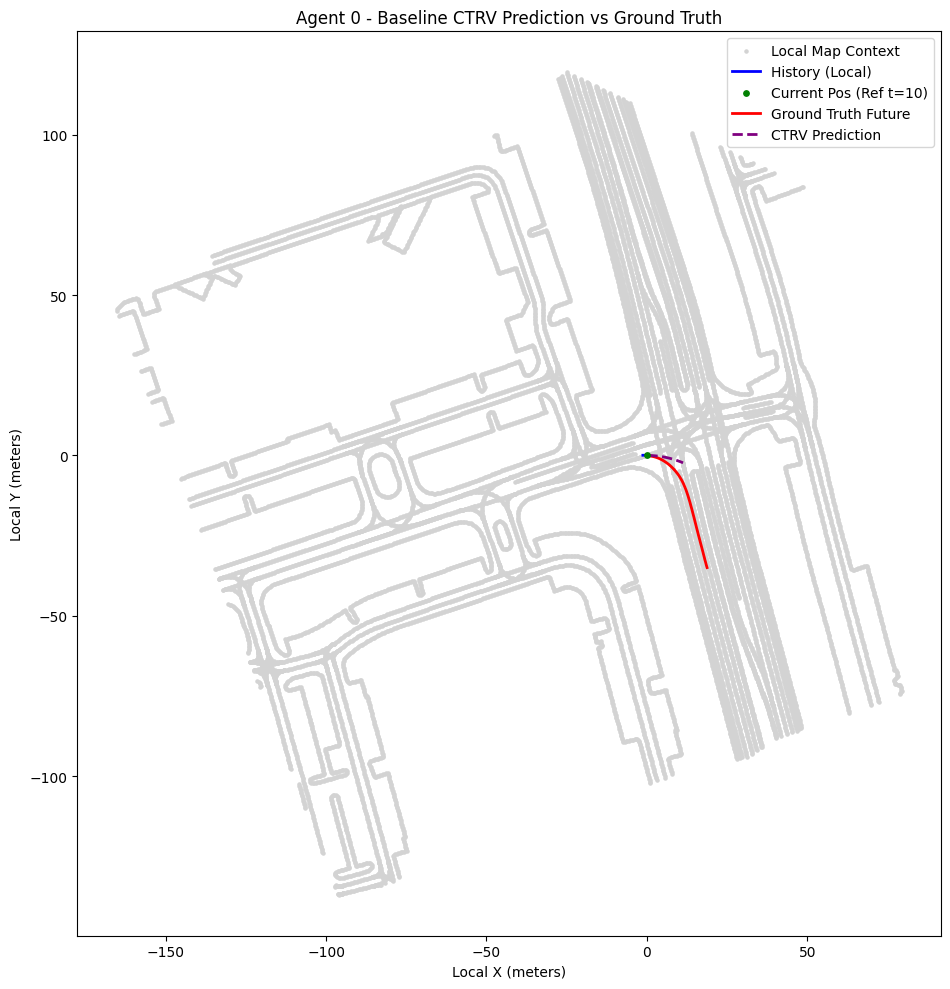

In [ ]:
import matplotlib.pyplot as plt

# Select the same target agent as before
target_agent_id = 0
agent_idx = list(df_training_ready['agent_id'].unique()).index(target_agent_id)

# Extract data for visualization
local_map = agent_centric_maps[target_agent_id]
hist_traj = history_tensor_np[agent_idx, :, :2]  # local_x, local_y
ground_truth_fut = future_tensor_np[agent_idx, :, :2]
pred_fut_ctrv = ctrv_pred_tensor_np[agent_idx, :, :2]

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot local map context
ax.scatter(local_map[:, 0], local_map[:, 1], color='lightgray', s=5, label='Local Map Context')

# Plot historical trajectory
ax.plot(hist_traj[:, 0], hist_traj[:, 1], color='blue', linewidth=2, label='History (Local)')
ax.scatter(hist_traj[-1, 0], hist_traj[-1, 1], color='green', s=15, label='Current Pos (Ref t=10)', zorder=5)

# Plot ground truth future trajectory
ax.plot(ground_truth_fut[:, 0], ground_truth_fut[:, 1], color='red', linewidth=2, label='Ground Truth Future')

# Plot predicted future trajectory
ax.plot(pred_fut_ctrv[:, 0], pred_fut_ctrv[:, 1], color='purple', linestyle='--', linewidth=2, label='CTRV Prediction')

ax.set_title(f'Agent {target_agent_id} - Baseline CTRV Prediction vs Ground Truth')
ax.set_xlabel('Local X (meters)')
ax.set_ylabel('Local Y (meters)')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()

## Baseline Evaluation
Evaluate the performance of the Constant Velocity (CV) and Constant Turn Rate and Velocity (CTRV) baseline prediction models using the Waymo open dataset validation bucket located at `"gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/"`.

## Access Validation Dataset for Testing

List and access the TFRecord files from the Waymo validation bucket directly via GCS.


In [22]:
import tensorflow as tf

# 1. Retrieve a list of all TFRecord file paths from the validation bucket
val_bucket_pattern = 'gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/*.tfrecord*'
val_files = tf.io.gfile.glob(val_bucket_pattern)

# 3. Print the number of files found to verify successful access
print(f'Number of validation files found: {len(val_files)}')

# 2. Instantiate a tf.data.TFRecordDataset using the retrieved list of GCS file paths
val_dataset = tf.data.TFRecordDataset(val_files)


Number of validation files found: 150


## Process Validation Scenarios

Parse scenarios from the validation dataset, filter for valid agents, and perform feature engineering (coordinate transformation and kinematic features).


In [23]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from waymo_open_dataset.protos import scenario_pb2

val_data = []

type_map = {
    scenario_pb2.Track.ObjectType.TYPE_UNSET: 'UNSET',
    scenario_pb2.Track.ObjectType.TYPE_VEHICLE: 'VEHICLE',
    scenario_pb2.Track.ObjectType.TYPE_PEDESTRIAN: 'PEDESTRIAN',
    scenario_pb2.Track.ObjectType.TYPE_CYCLIST: 'CYCLIST',
    scenario_pb2.Track.ObjectType.TYPE_OTHER: 'OTHER'
}
allowed_types = ['VEHICLE', 'PEDESTRIAN', 'CYCLIST']

# 1 & 2. Parse scenarios from validation dataset
num_scenarios = 100
for record in tqdm(val_dataset.take(num_scenarios), total=num_scenarios, desc="Parsing Scenarios"):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(record.numpy())

    # 3. Extract and filter agents
    for track in scenario.tracks:
        agent_type = type_map.get(track.object_type, 'UNKNOWN')
        if agent_type not in allowed_types:
            continue

        states = track.states
        if len(states) < 91:
            continue

        # Check validity for full history and final target
        has_full_history = all(states[i].valid for i in range(11))
        has_final_target = states[90].valid

        if not (has_full_history and has_final_target):
            continue

        # Use a unique agent_id across scenarios
        unique_agent_id = f"{scenario.scenario_id}_{track.id}"

        # 5. Extract states
        for step_index, state in enumerate(states):
            if step_index > 90:
                break # Only need up to step 90
            row = {
                'scenario_id': scenario.scenario_id,
                'agent_id': unique_agent_id,
                'agent_type': agent_type,
                'time_step': step_index,
                'valid': state.valid,
                'center_x': state.center_x,
                'center_y': state.center_y,
                'heading': state.heading,
                'velocity_x': state.velocity_x,
                'velocity_y': state.velocity_y
            }
            val_data.append(row)

df_val_scenario = pd.DataFrame(val_data)
print(f"Extracted {df_val_scenario['agent_id'].nunique()} valid agents and {len(df_val_scenario)} valid rows for validation.")

# 4. Agent-Centric Coordinate Transformation
df_val_ready = df_val_scenario.copy()
df_val_ready['local_x'] = 0.0
df_val_ready['local_y'] = 0.0
df_val_ready['local_heading'] = 0.0

for agent_id, group in tqdm(df_val_ready.groupby('agent_id'), desc="Transforming Coordinates"):
    ref_state = group[group['time_step'] == 10]
    if ref_state.empty:
        continue

    ref_x = ref_state['center_x'].values[0]
    ref_y = ref_state['center_y'].values[0]
    ref_heading = ref_state['heading'].values[0]

    idx = group.index
    dx = df_val_ready.loc[idx, 'center_x'] - ref_x
    dy = df_val_ready.loc[idx, 'center_y'] - ref_y

    cos_h = np.cos(-ref_heading)
    sin_h = np.sin(-ref_heading)

    df_val_ready.loc[idx, 'local_x'] = dx * cos_h - dy * sin_h
    df_val_ready.loc[idx, 'local_y'] = dx * sin_h + dy * cos_h
    df_val_ready.loc[idx, 'local_heading'] = df_val_ready.loc[idx, 'heading'] - ref_heading

# Kinematic Feature Extraction
df_val_ready['speed'] = np.sqrt(df_val_ready['velocity_x']**2 + df_val_ready['velocity_y']**2)
df_val_ready['acceleration'] = 0.0
df_val_ready['yaw_rate'] = 0.0

dt = 0.1
for agent_id, group in tqdm(df_val_ready.groupby('agent_id'), desc="Extracting Kinematics"):
    idx = group.index

    # Acceleration
    speed_diff = group['speed'].diff()
    speed_diff.iloc[0] = 0.0
    df_val_ready.loc[idx, 'acceleration'] = speed_diff / dt

    # Yaw rate
    heading_diff = group['heading'].diff()
    heading_diff.iloc[0] = 0.0
    heading_diff = (heading_diff + np.pi) % (2 * np.pi) - np.pi
    df_val_ready.loc[idx, 'yaw_rate'] = heading_diff / dt

print("Feature engineering complete. Validation data ready.")
display(df_val_ready.head())

Parsing Scenarios:   0%|          | 0/100 [00:00<?, ?it/s]

Extracted 1832 valid agents and 166712 valid rows for validation.


Transforming Coordinates:   0%|          | 0/1832 [00:00<?, ?it/s]

Extracting Kinematics:   0%|          | 0/1832 [00:00<?, ?it/s]

Feature engineering complete. Validation data ready.


,scenario_id,agent_id,agent_type,time_step,valid,center_x,center_y,heading,velocity_x,velocity_y,local_x,local_y,local_heading,speed,acceleration,yaw_rate
0,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,0,True,3578.349121,4986.538086,-1.520831,1.086426,-21.406250,-21.218126,-0.066254,-0.007576,21.433802,0.000000,0.000000
1,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,1,True,3578.459717,4984.412109,-1.518627,1.105957,-21.259766,-19.089307,-0.078104,-0.005371,21.288513,-1.452891,0.022043
2,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,2,True,3578.583740,4982.276855,-1.515478,1.240234,-21.352539,-16.950455,-0.077082,-0.002222,21.388527,1.000147,0.031494
3,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,3,True,3578.707520,4980.156738,-1.512703,1.237793,-21.201172,-14.826728,-0.075433,0.000553,21.237274,-1.512531,0.027751
4,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,4,True,3578.834229,4978.032715,-1.512416,1.267090,-21.240234,-12.698933,-0.071084,0.000840,21.277995,0.407207,0.002867


Extract the future target trajectories from the prepared validation DataFrame and structure them into a NumPy tensor to be used as ground truth for evaluating the baseline models.



In [24]:
import numpy as np

val_future_tensors = []
valid_agent_ids_val = []

for agent_id, agent_data in df_val_ready.groupby('agent_id'):
    # Extract future target coordinates (local_x, local_y) for time steps 11 to 90
    future_data = agent_data[(agent_data['time_step'] > 10) & (agent_data['time_step'] <= 90)].sort_values('time_step')

    # Ensure we have exactly 80 future steps
    if len(future_data) == 80:
        val_future_tensors.append(future_data[['local_x', 'local_y']].values)
        valid_agent_ids_val.append(agent_id)

val_future_tensor_np = np.array(val_future_tensors)

print(f"Validation valid agents count: {len(valid_agent_ids_val)}")
print(f"Validation future targets tensor shape: {val_future_tensor_np.shape}")

Validation valid agents count: 1832
Validation future targets tensor shape: (1832, 80, 2)


Apply Constant Velocity (CV) and Constant Turn Rate and Velocity (CTRV) models to the validation data and compute their Average Displacement Error (ADE) and Final Displacement Error (FDE) against the ground truth future tensors.



In [ ]:
import numpy as np

# Predict with CV model
df_cv_predictions_val = predict_cv_model(df_val_ready)

# Format CV predictions into tensor
cv_pred_tensors_val = []
for agent_id in valid_agent_ids_val:
    agent_preds = df_cv_predictions_val[df_cv_predictions_val['agent_id'] == agent_id]
    cv_pred_tensors_val.append(agent_preds[['pred_x_local', 'pred_y_local']].values)
cv_pred_tensor_val_np = np.array(cv_pred_tensors_val)

# Evaluate CV model
distances_cv_val = np.linalg.norm(cv_pred_tensor_val_np - val_future_tensor_np, axis=2)
ade_cv_val = np.mean(distances_cv_val)
fde_cv_val = np.mean(distances_cv_val[:, -1])

print(f"Validation Constant Velocity (CV) Model Performance:")
print(f"  Average Displacement Error (ADE): {ade_cv_val:.4f} meters")
print(f"  Final Displacement Error (FDE):   {fde_cv_val:.4f} meters\n")

# Predict with CTRV model
df_ctrv_predictions_val = predict_ctrv_model(df_val_ready)

# Format CTRV predictions into tensor
ctrv_pred_tensors_val = []
for agent_id in valid_agent_ids_val:
    agent_preds = df_ctrv_predictions_val[df_ctrv_predictions_val['agent_id'] == agent_id]
    ctrv_pred_tensors_val.append(agent_preds[['pred_x_local', 'pred_y_local']].values)
ctrv_pred_tensor_val_np = np.array(ctrv_pred_tensors_val)

# Evaluate CTRV model
distances_ctrv_val = np.linalg.norm(ctrv_pred_tensor_val_np - val_future_tensor_np, axis=2)
ade_ctrv_val = np.mean(distances_ctrv_val)
fde_ctrv_val = np.mean(distances_ctrv_val[:, -1])

print(f"Validation Constant Turn Rate and Velocity (CTRV) Model Performance:")
print(f"  Average Displacement Error (ADE): {ade_ctrv_val:.4f} meters")
print(f"  Final Displacement Error (FDE):   {fde_ctrv_val:.4f} meters")


Validation Constant Velocity (CV) Model Performance:
  Average Displacement Error (ADE): 18.9835 meters
  Final Displacement Error (FDE):   8.7663 meters

Validation Constant Turn Rate and Velocity (CTRV) Model Performance:
  Average Displacement Error (ADE): 19.0912 meters
  Final Displacement Error (FDE):   9.2308 meters


Histograms comparing the distribution of Final Displacement Errors (FDE) and Average Displacement Errors (ADE) across all valid validation agents.



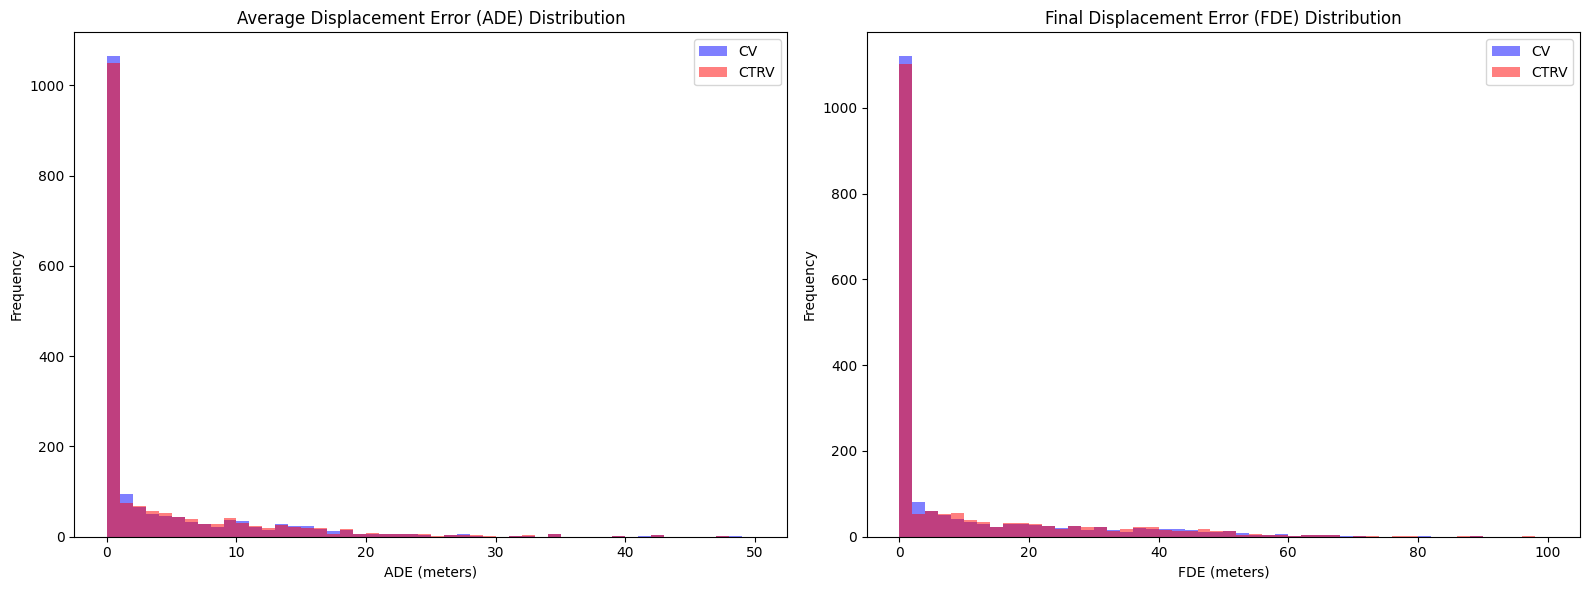

In [ ]:
import matplotlib.pyplot as plt

# Compute ADE and FDE per agent for CV
ade_cv_per_agent = np.mean(distances_cv_val, axis=1)
fde_cv_per_agent = distances_cv_val[:, -1]

# Compute ADE and FDE per agent for CTRV
ade_ctrv_per_agent = np.mean(distances_ctrv_val, axis=1)
fde_ctrv_per_agent = distances_ctrv_val[:, -1]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot ADE distribution
ax1.hist(ade_cv_per_agent, bins=50, alpha=0.5, label='CV', color='blue', range=(0, 50))
ax1.hist(ade_ctrv_per_agent, bins=50, alpha=0.5, label='CTRV', color='red', range=(0, 50))
ax1.set_title('Average Displacement Error (ADE) Distribution')
ax1.set_xlabel('ADE (meters)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Plot FDE distribution
ax2.hist(fde_cv_per_agent, bins=50, alpha=0.5, label='CV', color='blue', range=(0, 100))
ax2.hist(fde_ctrv_per_agent, bins=50, alpha=0.5, label='CTRV', color='red', range=(0, 100))
ax2.set_title('Final Displacement Error (FDE) Distribution')
ax2.set_xlabel('FDE (meters)')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()


## Summary:

### Data Analysis Key Findings
* **Dataset Access & Processing:** The script successfully accessed the Waymo validation bucket directly from Google Cloud Storage (GCS), locating 150 TFRecord files. Parsing a 100-scenario subset yielded 1,832 valid agents (comprising 166,712 valid rows) with complete required history and future targets.
* **Ground Truth Extraction:** Future trajectories for the 1,832 agents were successfully transformed into agent-centric local coordinates, producing a ground truth tensor shape of `(1832, 80, 2)`.
* **CV Model Performance:** The Constant Velocity (CV) baseline model achieved an Average Displacement Error (ADE) of 18.9835 meters and a Final Displacement Error (FDE) of 8.7663 meters.
* **CTRV Model Performance:** The Constant Turn Rate and Velocity (CTRV) baseline model yielded an ADE of 19.0912 meters and an FDE of 9.2308 meters.

### Insights
* **Baseline Comparison:** The Constant Velocity (CV) model slightly outperformed the Constant Turn Rate and Velocity (CTRV) model on both ADE and FDE metrics. This suggests that assuming a constant turn rate over an 8-second future horizon might introduce accumulating geometric errors compared to a simpler linear trajectory assumption.

## MLP

In [ ]:
print("Starting MLP Baseline Training...")
history_mlp = mlp_model.fit(
    train_dataset,
    epochs=EPOCHS
)
print("MLP Training Complete!")

Starting MLP Baseline Training...
Epoch 1/5
6973/6973 [==============================] - 2839s 407ms/step - loss: 109526.7031 - mae: 14.2931
Epoch 2/5
6973/6973 [==============================] - 2820s 404ms/step - loss: 109518.6875 - mae: 14.1827
Epoch 3/5
6973/6973 [==============================] - 2825s 405ms/step - loss: 109514.2500 - mae: 14.2797
Epoch 4/5
6973/6973 [==============================] - 2825s 405ms/step - loss: 109508.2344 - mae: 14.4096
Epoch 5/5
6973/6973 [==============================] - 2839s 407ms/step - loss: 109500.5703 - mae: 14.5995
MLP Training Complete!


## MLP Evaluation

## MLP - 10% Training dataset

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_mlp_baseline():
    # 1. Define Inputs
    history_input = layers.Input(shape=(11, 7), name='history')
    map_input = layers.Input(shape=(1000, 2), name='map_context')

    # 2. Process Historical Trajectory with an MLP (Flatten the time dimension)
    hist_flat = layers.Flatten()(history_input)
    hist_features = layers.Dense(64, activation='relu')(hist_flat)

    # 3. Process Map Context (Same simple PointNet-style as LSTM)
    map_feats = layers.Dense(32, activation='relu')(map_input)
    map_context_vector = layers.GlobalAveragePooling1D()(map_feats)

    # 4. Combine features
    combined = layers.Concatenate()([hist_features, map_context_vector])

    # 5. MLP Head for Prediction
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.Dense(160, activation='linear')(x) # 80 steps * 2 (X, Y)

    # 6. Reshape to match the target tensor (80, 2)
    output = layers.Reshape((80, 2))(x)

    model = Model(inputs=[history_input, map_input], outputs=output, name="MLP_Baseline")
    return model

mlp_model_10p = build_mlp_baseline()
mlp_model_10p.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

mlp_model_10p.summary()

Model: "MLP_Baseline"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 history (InputLayer)        [(None, 11, 7)]              0         []                            
                                                                                                  
 map_context (InputLayer)    [(None, 1000, 2)]            0         []                            
                                                                                                  
 flatten_2 (Flatten)         (None, 77)                   0         ['history[0][0]']             
                                                                                                  
 dense_9 (Dense)             (None, 1000, 32)             96        ['map_context[0][0]']         
                                                                                       

In [27]:
EPOCHS = 5

print("Starting MLP Baseline Training...")
history_mlp = mlp_model_10p.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset_for_training
)
print("MLP Training Complete!")

Starting MLP Baseline Training...
Epoch 1/5
13854/13854 [==============================] - 6552s 473ms/step - loss: 13.1768 - mae: 13.3348 - val_loss: 13.3505 - val_mae: 13.4988
Epoch 2/5
13854/13854 [==============================] - 7164s 517ms/step - loss: 13.0543 - mae: 13.2024 - val_loss: 13.3004 - val_mae: 13.4452
Epoch 3/5
13854/13854 [==============================] - 6893s 497ms/step - loss: 13.0235 - mae: 13.1688 - val_loss: 13.2846 - val_mae: 13.4293
Epoch 4/5
13854/13854 [==============================] - 5981s 432ms/step - loss: 13.0089 - mae: 13.1526 - val_loss: 13.2747 - val_mae: 13.4164
Epoch 5/5
13854/13854 [==============================] - 5720s 413ms/step - loss: 12.9995 - mae: 13.1424 - val_loss: 13.2742 - val_mae: 13.4151
MLP Training Complete!


## Saving the trained model

In [28]:
# Save the model trained on 10% of the dataset
mlp_model_10p.save('mlp_model_10p.keras')
print("mlp_model_10p saved successfully as 'mlp_model_10p.keras'!")

mlp_model_10p saved successfully as 'mlp_model_10p.keras'!


In [29]:
from google.colab import drive
import shutil

# Mount your Google Drive (if not already mounted)
drive.mount('/content/drive')

# Copy the model to your Google Drive
shutil.copy('mlp_model_10p.keras', '/content/drive/MyDrive/mlp_model_10p.keras')
print("mlp_model_10p successfully copied to Google Drive!")

Mounted at /content/drive
mlp_model_10p successfully copied to Google Drive!


## Reusing saved model

In [ ]:
import tensorflow as tf

# To reuse the model in a new session, you simply load it from the saved path:
loaded_model_path = '/content/drive/MyDrive/mlp_model_10p.keras'

print(f"Loading model from {loaded_model_path}...")
loaded_mlp_model = tf.keras.models.load_model(loaded_model_path)

# Verify it loaded correctly by checking the architecture
loaded_mlp_model.summary()

# Now you can use 'loaded_mlp_model' to make predictions or continue training
# without spending hours retraining!
# Example:
# predictions = loaded_mlp_model.predict({'history': hist_input, 'map_context': map_input})

## Quick Test (small test set)

In [30]:
import numpy as np

print("Evaluating mlp_model_10p on Validation Dataset (100 Scenarios)...")

# 1. Create a validation dataset pipeline using our existing generator
# Explicitly set max_scenarios=100 to match the physics baseline evaluation
val_dataset_mlp_10p = tf.data.Dataset.from_generator(
    lambda: waymo_generator(val_files, max_scenarios=100),
    output_signature=output_signature
).batch(BATCH_SIZE)

# 2. Collect predictions and ground truth
all_mlp_10p_preds = []
all_mlp_10p_targets = []

for inputs, targets in val_dataset_mlp_10p:
    # Generate predictions for the batch
    preds = mlp_model_10p.predict(inputs, verbose=0)
    all_mlp_10p_preds.append(preds)
    all_mlp_10p_targets.append(targets.numpy())

# 3. Concatenate all batches into single numpy arrays
all_mlp_10p_preds_np = np.concatenate(all_mlp_10p_preds, axis=0)
all_mlp_10p_targets_np = np.concatenate(all_mlp_10p_targets, axis=0)

# 4. Calculate ADE and FDE
distances_mlp_10p = np.linalg.norm(all_mlp_10p_preds_np - all_mlp_10p_targets_np, axis=2)

ade_mlp_10p = np.mean(distances_mlp_10p)
fde_mlp_10p = np.mean(distances_mlp_10p[:, -1])

print(f"\nmlp_model_10p Performance on Validation Set (100 Scenarios):")
print(f"  Average Displacement Error (ADE): {ade_mlp_10p:.4f} meters")
print(f"  Final Displacement Error (FDE):   {fde_mlp_10p:.4f} meters")

Evaluating mlp_model_10p on Validation Dataset (100 Scenarios)...

mlp_model_10p Performance on Validation Set (100 Scenarios):
  Average Displacement Error (ADE): 17.7356 meters
  Final Displacement Error (FDE):   5.6169 meters


## Plot

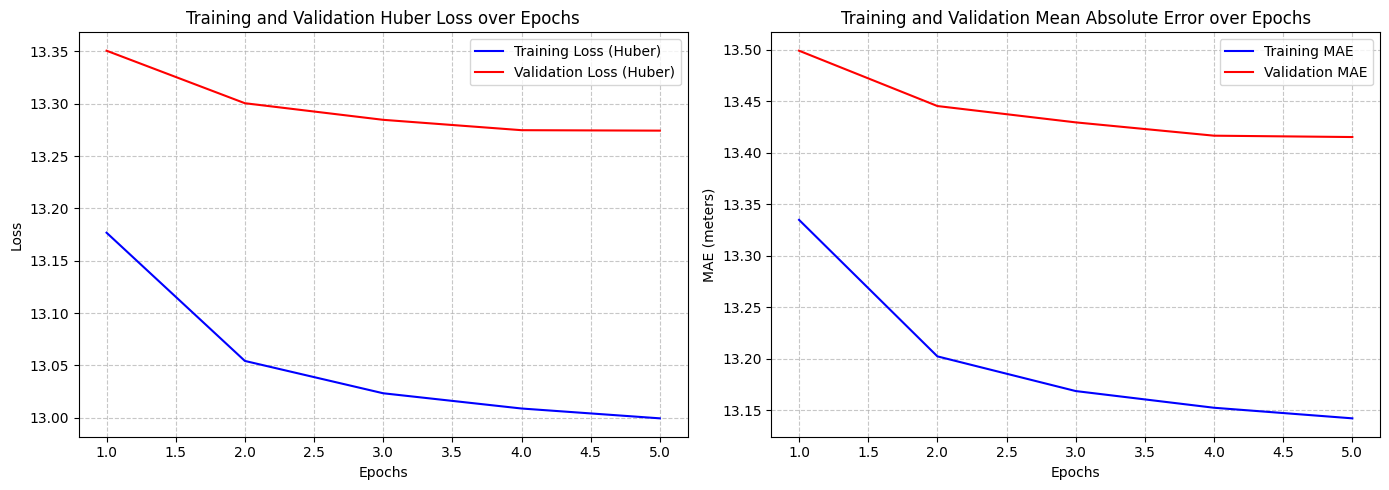

In [31]:
import matplotlib.pyplot as plt

# Extract the metrics from the history object (from the 10% model training)
loss = history_mlp.history['loss']
val_loss = history_mlp.history['val_loss']
mae = history_mlp.history['mae']
val_mae = history_mlp.history['val_mae']
epochs = range(1, len(loss) + 1)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss (Huber)
ax1.plot(epochs, loss, 'b-', label='Training Loss (Huber)')
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss (Huber)')
ax1.set_title('Training and Validation Huber Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot MAE
ax2.plot(epochs, mae, 'b-', label='Training MAE')
ax2.plot(epochs, val_mae, 'r-', label='Validation MAE')
ax2.set_title('Training and Validation Mean Absolute Error over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MAE (meters)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Sample trajectory

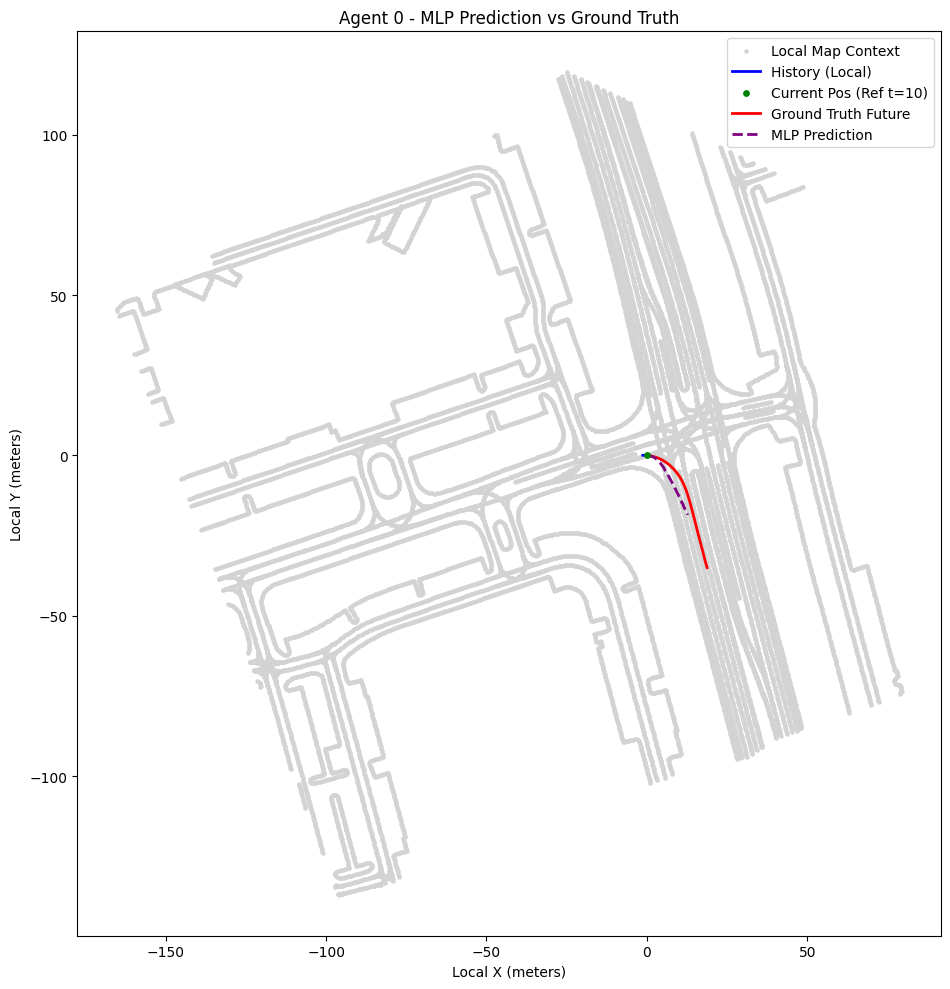

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Select the same target agent as before
target_agent_id = 0
agent_idx = list(df_training_ready['agent_id'].unique()).index(target_agent_id)

# 1. Prepare history input
hist_input = history_tensor_np[agent_idx:agent_idx+1] # Shape (1, 11, 7)

# 2. Prepare map context input (need exactly 1000 points for the MLP)
local_map_raw = agent_centric_maps[target_agent_id]
if len(local_map_raw) > 1000:
    # Take the closest 1000 points
    dists = np.linalg.norm(local_map_raw, axis=1)
    closest_idx = np.argsort(dists)[:1000]
    local_map_padded = local_map_raw[closest_idx]
elif len(local_map_raw) < 1000:
    # Pad with zeros
    pad_size = 1000 - len(local_map_raw)
    local_map_padded = np.pad(local_map_raw, ((0, pad_size), (0, 0)), mode='constant')
else:
    local_map_padded = local_map_raw

map_input = np.expand_dims(local_map_padded, axis=0) # Shape (1, 1000, 2)

# 3. Generate prediction using the 10% MLP model
pred_fut_mlp = mlp_model_10p.predict({'history': hist_input, 'map_context': map_input}, verbose=0)
pred_fut_mlp = pred_fut_mlp[0] # Shape (80, 2)

# 4. Extract data for visualization
hist_traj = history_tensor_np[agent_idx, :, :2]  # local_x, local_y
ground_truth_fut = future_tensor_np[agent_idx, :, :2]

# 5. Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot local map context (using the raw map for better visual context)
ax.scatter(local_map_raw[:, 0], local_map_raw[:, 1], color='lightgray', s=5, label='Local Map Context')

# Plot historical trajectory
ax.plot(hist_traj[:, 0], hist_traj[:, 1], color='blue', linewidth=2, label='History (Local)')
ax.scatter(hist_traj[-1, 0], hist_traj[-1, 1], color='green', s=15, label='Current Pos (Ref t=10)', zorder=5)

# Plot ground truth future trajectory
ax.plot(ground_truth_fut[:, 0], ground_truth_fut[:, 1], color='red', linewidth=2, label='Ground Truth Future')

# Plot predicted future trajectory
ax.plot(pred_fut_mlp[:, 0], pred_fut_mlp[:, 1], color='purple', linestyle='--', linewidth=2, label='MLP Prediction')

ax.set_title(f'Agent {target_agent_id} - MLP Prediction vs Ground Truth')
ax.set_xlabel('Local X (meters)')
ax.set_ylabel('Local Y (meters)')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()

## Test on 25 validation files (80:20 rule)

In [1]:
import numpy as np
import tensorflow as tf
import time

subset_val_files = val_files[:25]
print(f"Setting up dataset with {len(subset_val_files)} validation files...")

# Create streaming dataset
val_dataset_25 = tf.data.Dataset.from_generator(
    lambda: waymo_generator(subset_val_files, max_scenarios=None),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Evaluating Physics Baselines (CV & CTRV) on 25 Validation Files...")

cv_ades, cv_fdes = [], []
ctrv_ades, ctrv_fdes = [], []

# Future time steps for projection
dt_steps = np.arange(1, 81) * 0.1 # shape (80,)

total_inference_time_cv = 0.0
total_inference_time_ctrv = 0.0
total_agents = 0

for inputs, targets in val_dataset_25:
    history = inputs['history'].numpy()
    target_fut = targets.numpy()

    # Extract t=10 kinematics
    speed = history[:, 10, 3:4] # shape (batch, 1)
    yaw_rate = history[:, 10, 5:6] # shape (batch, 1)

    # 1. CV Prediction (Local frame: heading is 0, so velocity is exactly along X-axis)
    t_start_cv = time.time()
    cv_pred_x = speed * dt_steps # (batch, 80)
    cv_pred_y = np.zeros_like(cv_pred_x)
    cv_pred = np.stack([cv_pred_x, cv_pred_y], axis=-1) # (batch, 80, 2)
    total_inference_time_cv += (time.time() - t_start_cv)

    # 2. CTRV Prediction
    t_start_ctrv = time.time()
    yaw_rate_safe = np.where(np.abs(yaw_rate) < 1e-4, 1e-4, yaw_rate)
    ctrv_pred_x = (speed / yaw_rate_safe) * np.sin(yaw_rate_safe * dt_steps)
    ctrv_pred_y = (speed / yaw_rate_safe) * (1 - np.cos(yaw_rate_safe * dt_steps))
    ctrv_pred = np.stack([ctrv_pred_x, ctrv_pred_y], axis=-1)

    # Fallback to CV if yaw_rate is too small
    mask = np.abs(yaw_rate) < 1e-4
    mask = np.expand_dims(mask, axis=-1)
    ctrv_pred = np.where(mask, cv_pred, ctrv_pred)
    total_inference_time_ctrv += (time.time() - t_start_ctrv)

    total_agents += len(speed)

    # Metrics CV
    cv_dist = np.linalg.norm(cv_pred - target_fut, axis=2)
    cv_ades.append(np.mean(cv_dist, axis=1))
    cv_fdes.append(cv_dist[:, -1])

    # Metrics CTRV
    ctrv_dist = np.linalg.norm(ctrv_pred - target_fut, axis=2)
    ctrv_ades.append(np.mean(ctrv_dist, axis=1))
    ctrv_fdes.append(ctrv_dist[:, -1])

latency_ms_per_agent_cv = (total_inference_time_cv / total_agents) * 1000 if total_agents > 0 else 0
latency_ms_per_agent_ctrv = (total_inference_time_ctrv / total_agents) * 1000 if total_agents > 0 else 0

print(f"\nConstant Velocity (CV) Performance:")
print(f"  ADE: {np.mean(np.concatenate(cv_ades)):.4f} meters")
print(f"  FDE: {np.mean(np.concatenate(cv_fdes)):.4f} meters")
print(f"  Average Inference Latency: {latency_ms_per_agent_cv:.4f} ms / agent")

print(f"\nConstant Turn Rate and Velocity (CTRV) Performance:")
print(f"  ADE: {np.mean(np.concatenate(ctrv_ades)):.4f} meters")
print(f"  FDE: {np.mean(np.concatenate(ctrv_fdes)):.4f} meters")
print(f"  Average Inference Latency: {latency_ms_per_agent_ctrv:.4f} ms / agent")

NameError: name 'val_files' is not defined

In [34]:
import time

print("Evaluating MLP (10% Training Data) on 25 Validation Files...")

mlp_10p_ades, mlp_10p_fdes = [], []
total_inference_time = 0.0
total_agents = 0

for inputs, targets in val_dataset_25:
    t_start = time.time()
    preds = mlp_model_10p.predict_on_batch(inputs)
    total_inference_time += (time.time() - t_start)

    dist = np.linalg.norm(preds - targets.numpy(), axis=2)

    mlp_10p_ades.append(np.mean(dist, axis=1))
    mlp_10p_fdes.append(dist[:, -1])
    total_agents += preds.shape[0]

latency_ms_per_agent = (total_inference_time / total_agents) * 1000 if total_agents > 0 else 0

print(f"\nMLP (10% Data) Performance:")
print(f"  ADE: {np.mean(np.concatenate(mlp_10p_ades)):.4f} meters")
print(f"  FDE: {np.mean(np.concatenate(mlp_10p_fdes)):.4f} meters")
print(f"  Average Inference Latency: {latency_ms_per_agent:.4f} ms / agent")

Evaluating MLP (10% Training Data) on 25 Validation Files...

MLP (10% Data) Performance:
  ADE: 20.6155 meters
  FDE: 5.5126 meters
  Average Inference Latency: 0.6331 ms / agent


In [5]:
import tensorflow as tf

# 1. Fetch the file list directly
bucket_pattern = 'gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/training/*.tfrecord*'

try:
    all_files = tf.io.gfile.glob(bucket_pattern)
except tf.errors.PermissionDeniedError:
    all_files = []
    print("Permission Denied: Your Google Cloud authentication has expired or is missing.")
    print("Please run the cell at the top of the notebook containing `auth.authenticate_user()` to re-authenticate.")

if not all_files:
    print("\nNo files found or access denied. Please re-authenticate and try again.")
else:
    # Take the first 100 files
    files_to_process = all_files[:100]
    print(f"Counting total scenarios across {len(files_to_process)} files. This might take a moment...\n")

    # Load the dataset from the list of 100 files
    dataset = tf.data.TFRecordDataset(files_to_process)

    total_scenarios = 0
    # We don't need to parse the protobufs just to count records,
    # iterating through the raw dataset directly is much faster!
    for _ in dataset:
        total_scenarios += 1

    print(f"Total scenarios in the first 100 files: {total_scenarios}")


Counting total scenarios across 100 files. This might take a moment...

Total scenarios in the first 100 files: 48805
